In [4]:
from IPython.display import display, HTML, Image
display(HTML("<style>.container { width:100% !important; }</style>"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from tqdm import tqdm

from scipy.stats import chi2_contingency, chi2, ttest_ind_from_stats, norm, binom, mannwhitneyu, t, chisquare
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

from datetime import datetime
pd.set_option('display.max_colwidth', None)

from exp_tools.stat_tools import *

import plotly.offline as pyo
import plotly.io as pio
pio.renderers.default = 'iframe'

## Known Issues in `exp_tools/stat_tools.py`

The following bugs exist in the underlying library and are noted here for awareness:

1. **`calculate_req_traffic_for_power` is defined twice** — the second definition (lines 473-479) silently overrides the first (lines 434-439). They use different formulas. The second (active) version returns `n_variant` per arm.

2. **`calculate_mde_from_traffic` uses the global variable `BASE_RATE`** instead of its `base_rate` parameter (`return mde / BASE_RATE`). This makes the function result depend on whatever `BASE_RATE` happens to be in scope — a latent bug.

These are not fixed in this notebook (they are in `stat_tools.py`) but callers should be aware.

In [5]:
def vertical_plot_lines(x, xal, yal, **kwargs):
    plt.axvline(x.mean(), linestyle='--', color=kwargs.get("color", "g"), alpha=0.5)
    tx_mean = "mean: {:.1%}".format(x.mean())
    txkw = dict(size=11, color=kwargs.get("color", "g"), rotation=90)
    plt.text(x.mean() + xal, yal, tx_mean, **txkw)


def draw_heatmap(data, row_var, col_var, value_var, **kwargs):
    data_pivot = data.pivot(index=row_var, columns=col_var, values=value_var)
    sns.heatmap(data_pivot, **kwargs)


def annotate_mean(data, metric, **kwargs):
    tx_mean = f"% Sig. results:{data[metric].mean():.0%}"
    plt.text(3.5, 9.5, tx_mean, dict(size=12))

### Local overrides of `get_results` / `get_ci`

The versions in `stat_tools` print to stdout and return `None`. These local versions are silent (no print) and **return a dict** `{estimate, ci_l, ci_h, p-value}` so they can be used inside simulation loops.

In [6]:
def get_results(data, metric_field, confidence=0.9, threshold=None, calculate_ratio=True, **kwargs):
    """Silent version that returns a result dict instead of printing."""
    df_stats = get_df_stats(data, metric_field)
    stats = get_stats(df_stats, non_inferioirity_threshold=threshold)

    if threshold is not None:
        confidence = 1 - (1 - confidence) * 2

    if kwargs.get('mannwhitney'):
        get_mann_whitney_test(data, metric_field, confidence)

    plot_arg = kwargs.get('plot', False)

    estimate, ci_l, ci_h = get_ci(
        df_stats,
        metric_field,
        confidence=confidence,
        plot=plot_arg,
        non_inferioirty_threshold=threshold,
        ratio=calculate_ratio
    )

    return {
        'estimate': estimate,
        'ci_l': ci_l,
        'ci_h': ci_h,
        'p-value': stats['p-value']
    }


def get_ci(df_stats, metric_field, confidence=0.9, plot=True, non_inferioirty_threshold=None, ratio=True):
    """Silent version that returns (estimate, ci_l, ci_h)."""
    if df_stats['binary'].all():
        estimate, ci_l, ci_h = improv_interval_binomial(
            confidence=confidence,
            successes_base=df_stats.at[0, 'reached_goal'],
            successes_var=df_stats.at[1, 'reached_goal'],
            obs_base=df_stats.at[0, 'visitors'],
            obs_var=df_stats.at[1, 'visitors']
        )
    else:
        if ratio:
            estimate, ci_l, ci_h = confidence_interval_ratio(
                confidence=confidence,
                avg_base=df_stats.at[0, 'reached_goal'] / df_stats.at[0, 'visitors'],
                avg_var=df_stats.at[1, 'reached_goal'] / df_stats.at[1, 'visitors'],
                stdev_base=df_stats.at[0, 'stdv'],
                stdev_var=df_stats.at[1, 'stdv'],
                obs_base=df_stats.at[0, 'visitors'],
                obs_var=df_stats.at[1, 'visitors']
            )
        else:
            estimate, ci_l, ci_h = confidence_interval_mean_differences(
                confidence=confidence,
                avg_base=df_stats.at[0, 'reached_goal'] / df_stats.at[0, 'visitors'],
                avg_var=df_stats.at[1, 'reached_goal'] / df_stats.at[1, 'visitors'],
                stdev_base=df_stats.at[0, 'stdv'],
                stdev_var=df_stats.at[1, 'stdv'],
                obs_base=df_stats.at[0, 'visitors'],
                obs_var=df_stats.at[1, 'visitors']
            )

    if ci_h < ci_l:
        ci_l, ci_h = min(ci_l, ci_h), max(ci_l, ci_h)

    if plot:
        plot_ci(estimate, ci_l, ci_h, metric_field,
                non_inferioirty_threshold=non_inferioirty_threshold, ratio=ratio)

    return estimate, ci_l, ci_h

# Sample Size & Power Calculations

Standard two-proportion z-test sample size formula:

$$n_{per\ arm} = \frac{2 \sigma^2 (z_{\alpha/2} + z_{\beta})^2}{\delta^2}$$

where $\sigma^2 = p_0(1-p_0)$ and $\delta = p_0 \cdot \text{MDE}_{rel}$ (absolute MDE).

In [7]:
def calculate_req_traffic_for_power(alpha, beta, base_rate, expected_effect):
    """Return required sample size per arm for a two-sided two-proportion z-test.
    
    Parameters
    ----------
    alpha          : two-sided significance level (e.g. 0.05)
    beta           : 1 - power (e.g. 0.2 for 80% power)
    base_rate      : baseline conversion rate
    expected_effect: minimum detectable relative lift (e.g. 0.05 = 5%)
    """
    za = norm.ppf(1 - alpha / 2)
    zb = norm.ppf(1 - beta)
    mde = base_rate * expected_effect          # absolute MDE
    sigma = np.sqrt(base_rate * (1 - base_rate))
    n_variant = 2 * sigma**2 * (za + zb)**2 / mde**2
    return int(n_variant)


def calculate_mde_from_traffic(alpha, beta, base_rate, n_variant):
    """Return minimum detectable relative effect given per-arm traffic."""
    za = norm.ppf(1 - alpha / 2)
    zb = norm.ppf(1 - beta)
    sigma = np.sqrt(base_rate * (1 - base_rate))
    mde_abs = np.sqrt(2 * sigma**2 * (za + zb)**2 / n_variant)
    return mde_abs / base_rate   # FIX: use parameter, not global BASE_RATE


ALPHA = 0.05
BETA  = 0.2          # 1 - power
BASE_RATE = 0.05
N_VARIANT = 20_000
EXPECTED_UPLIFT_PERC = 0.05
N_VARIANTS = 2
N_DAYS = 14

print(
    f'MDE (absolute) = +- {BASE_RATE * EXPECTED_UPLIFT_PERC:.2%}',
    f'\nEffect range [{BASE_RATE*(1-EXPECTED_UPLIFT_PERC):.2%}, {BASE_RATE*(1+EXPECTED_UPLIFT_PERC):.2%}]\n------'
)

req_n = calculate_req_traffic_for_power(
    alpha=ALPHA, beta=BETA, base_rate=BASE_RATE, expected_effect=EXPECTED_UPLIFT_PERC)

print(f'{req_n:,}\t=== Required visitors per arm')
print(f'{req_n/N_DAYS:,.0f}\t=== Required daily visitors per arm for {N_DAYS}-day run')
print(f'{req_n*N_VARIANTS:,}\t=== Total required visitors\n--------')

actual_mde = calculate_mde_from_traffic(
    alpha=ALPHA, beta=BETA, base_rate=BASE_RATE, n_variant=req_n)
print(f'Back-calculated MDE from traffic = {actual_mde:.4%} (should equal {EXPECTED_UPLIFT_PERC:.4%})')

MDE (absolute) = +- 0.25% 
Effect range [4.75%, 5.25%]
------
119,302	=== Required visitors per arm
8,522	=== Required daily visitors per arm for 14-day run
238,604	=== Total required visitors
--------
Back-calculated MDE from traffic = 5.0000% (should equal 5.0000%)


# Power Simulation: Effect Size × Sample Size Grid

We sweep over true effect sizes `[3%, 4%, 5%, 6%, 7%]` and, for each, compute the **powered sample size** (the N required to detect that exact effect at 80% power / α=10%). We then run **100 simulated experiments per cell** and measure what fraction are detected as significant (hit rate ≈ power).

> **Reading the heatmaps:** Each square in the 10×10 grid represents one simulated experiment. Blue = significant at α=10%; red = not significant. The annotation shows the empirical detection rate for that (sample_size, true_effect) combination.

> When the sample size is powered for the matching true effect, we should see ~80% blue squares on the diagonal cells.

In [8]:
ALPHA = 0.1        # two-sided significance level for all power simulations
BETA  = 0.2
BASE_RATE = 0.05

true_effects = [0.03, 0.04, 0.05, 0.06, 0.07]

# For each true effect, compute the powered total sample size (2 arms)
sample_sizes = [
    calculate_req_traffic_for_power(alpha=ALPHA, beta=BETA,
                                     base_rate=BASE_RATE, expected_effect=te) * 2
    for te in true_effects
]

print('Powered sample sizes (total, 2 arms):')
for te, ss in zip(true_effects, sample_sizes):
    print(f'  true_effect={te:.0%}  =>  N={ss:,}')

responses = {}
for sample_size in sample_sizes:
    for true_effect in true_effects:
        for i in tqdm(range(100), desc=f'ss={sample_size}, te={true_effect}', leave=False):
            df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
            df_exp['metric'] = np.random.binomial(n=1, p=BASE_RATE, size=sample_size)
            df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
                n=1,
                p=BASE_RATE * (1 + true_effect),
                size=df_exp.loc[df_exp.variant == 1].shape[0]
            )

            response = get_results(
                df_exp, metric_field='metric',
                confidence=0.9, threshold=None, calculate_ratio=True, plot=False
            )
            response['true_effect']  = true_effect
            response['sample_size']  = sample_size
            response['index_row']    = int(i // 10)
            response['index_col']    = int(i % 10)
            responses[f'{true_effect},{sample_size},{i}'] = response

stats = pd.DataFrame(responses).T
stats['sample_size'] = stats['sample_size'].astype(int)
stats['sig_at']      = (stats['p-value'] <= ALPHA).astype(int)
stats['count_sig']   = stats.groupby(['true_effect', 'sample_size', 'sig_at'])['sig_at'].transform('count')

Powered sample sizes (total, 2 arms):
  true_effect=3%  =>  N=522,082
  true_effect=4%  =>  N=293,670
  true_effect=5%  =>  N=187,948
  true_effect=6%  =>  N=130,520
  true_effect=7%  =>  N=95,892


ss=522082, te=0.03:   0%|                                                                                                                                                                                                                               | 0/100 [00:00<?, ?it/s]


pval = 0.88012, significant at 10%: False


pval = 0.00493, significant at 10%: True



ss=522082, te=0.03:   3%|██████▍                                                                                                                                                                                                                | 3/100 [00:00<00:03, 26.24it/s]


pval = 0.23029, significant at 10%: False


pval = 0.00047, significant at 10%: True



...

ss=95892, te=0.07:  75%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                     | 75/100 [00:00<00:00, 142.16it/s]


pval = 0.75103, significant at 10%: False


pval = 0.10101, significant at 10%: False


pval = 0.07565, significant at 10%: True


pval = 0.00668, significant at 10%: True


pval = 0.00497, significant at 10%: True


pval = 0.00699, significant at 10%: True


pval = 0.01706, significant at 10%: True


pval = 0.01617, significant at 10%: True


pval = 0.26071, significant at 10%: False


pval = 0.06201, significant at 10%: True


pval = 0.00054, significant at 10%: True


pval = 0.19182, significant at 10%: False


pval = 0.05926, significant at 10%: True


pval = 0.00060, significant at 10%: True


pval = 0.04410, significant at 10%: True



ss=95892, te=0.07:  90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                     | 90/100 [00:00<00:00, 141.06it/s]


pval = 0.00912, significant at 10%: True


pval = 0.00013, significant at 10%: True


pval = 0.06388, significant at 10%: True


pval = 0.00072, significant at 10%: True


pval = 0.00050, significant at 10%: True


pval = 0.01643, significant at 10%: True


pval = 0.18283, significant at 10%: False


pval = 0.00623, significant at 10%: True


pval = 0.00309, significant at 10%: True


pval = 0.00087, significant at 10%: True


pval = 0.01734, significant at 10%: True




pval = 0.00956, significant at 10%: True



## Heatmap: Detection Rate per (Sample Size, True Effect)

**Diagonal cells** (sample size is powered exactly for that true effect) should show ~80% detection. Off-diagonal cells show what happens when the experiment is under- or over-powered for the observed effect.

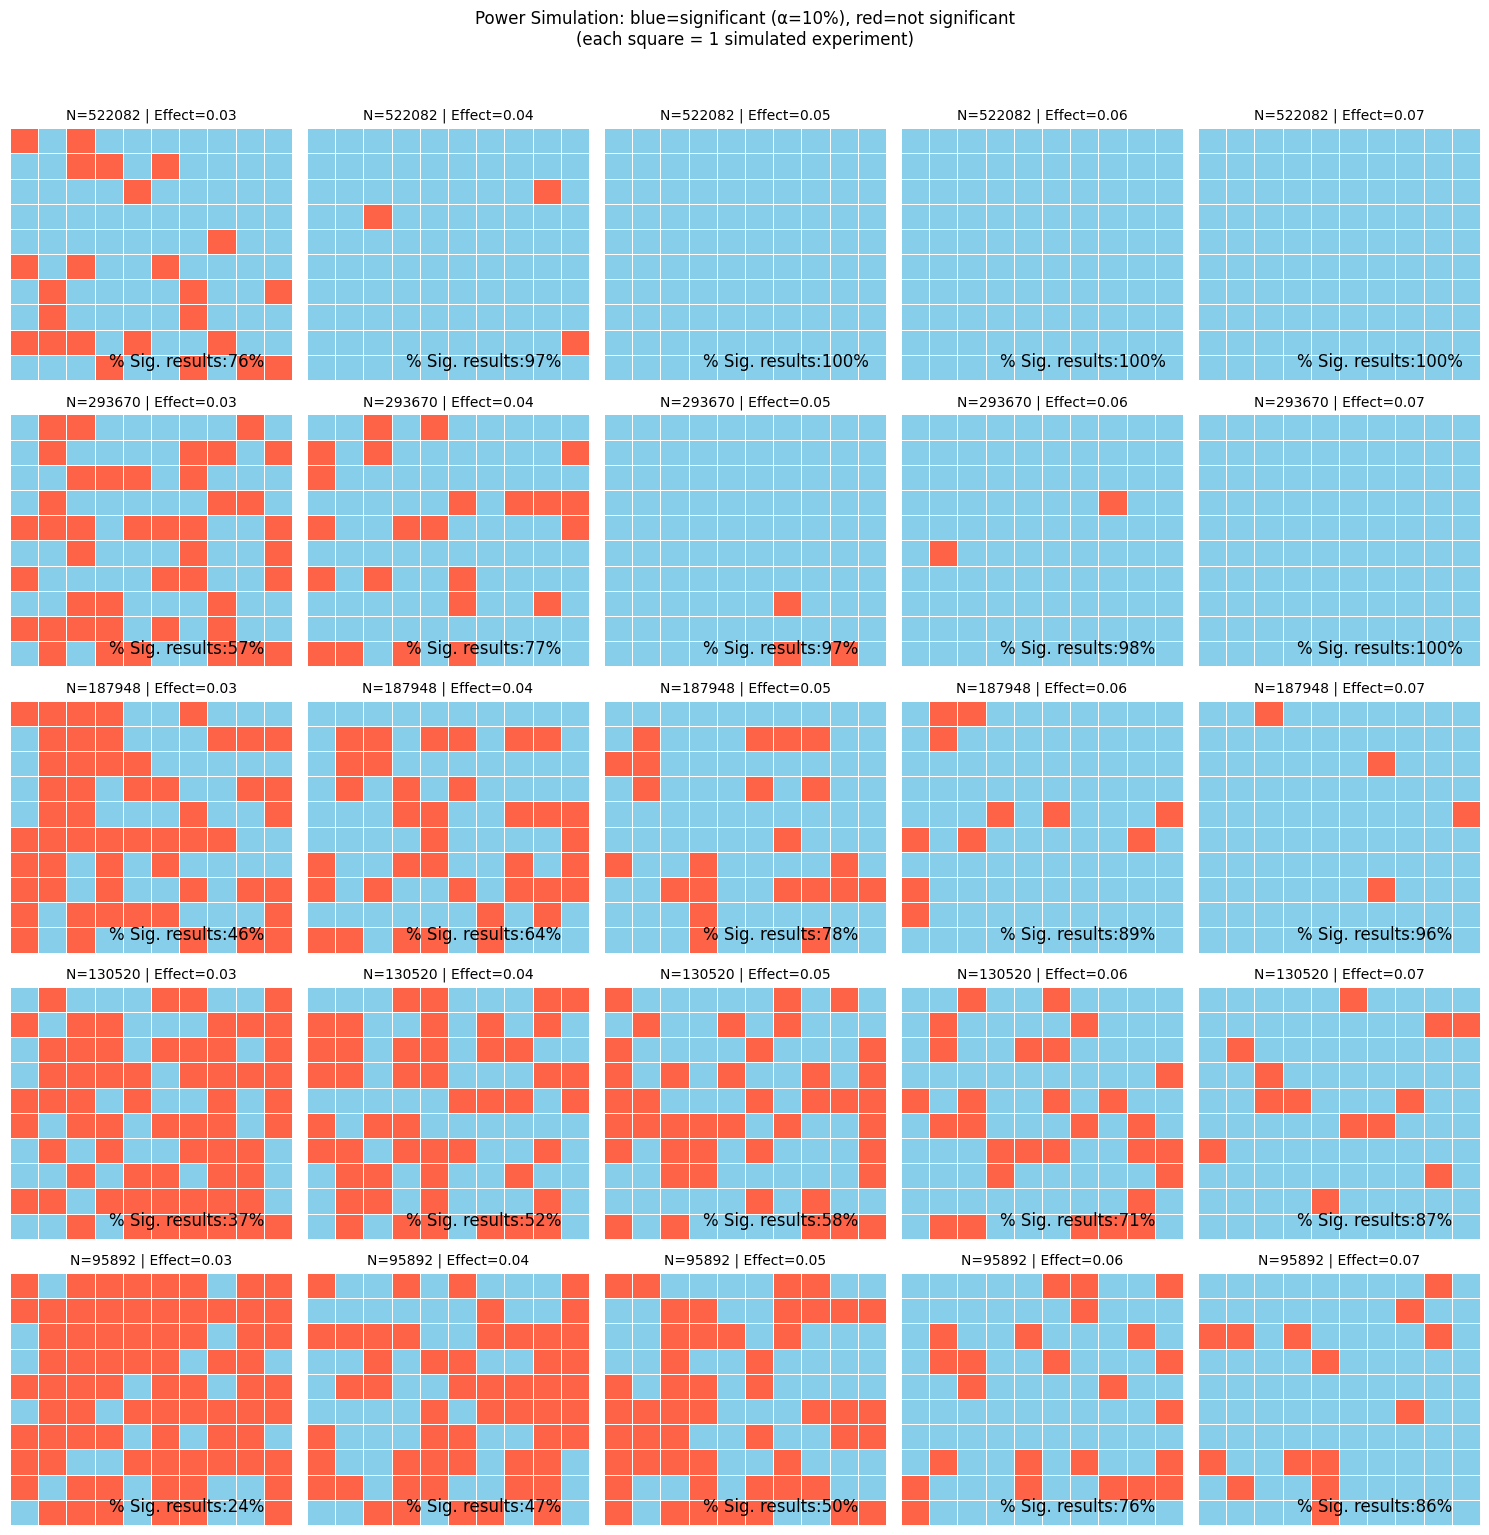

In [9]:
g = sns.FacetGrid(
    stats,
    col='true_effect',
    row='sample_size',
    height=3, aspect=1,
    row_order=sample_sizes
)
g.map_dataframe(draw_heatmap,
                row_var='index_row', col_var='index_col', value_var='sig_at',
                vmin=0, vmax=1,
                cmap=ListedColormap(['tomato', 'skyblue']),
                annot=False, linewidth=0.5, alpha=1, cbar=False)
g.map_dataframe(annotate_mean, metric='sig_at')

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

g.set_titles(row_template='N={row_name}', col_template='Effect={col_name}')
g.figure.suptitle('Power Simulation: blue=significant (α=10%), red=not significant\n(each square = 1 simulated experiment)', y=1.02)
g.figure.tight_layout()

## CI Distribution Across 100 Experiments

For a fixed true effect of 5% and its powered N, we plot the CI [low, high] band for each of the 100 simulations. This visualises:
- How much the CI shifts experiment to experiment (sampling variability)
- Whether the CI includes the true effect (green dashed line)
- ~90% of CIs should contain the true effect (90% confidence level)

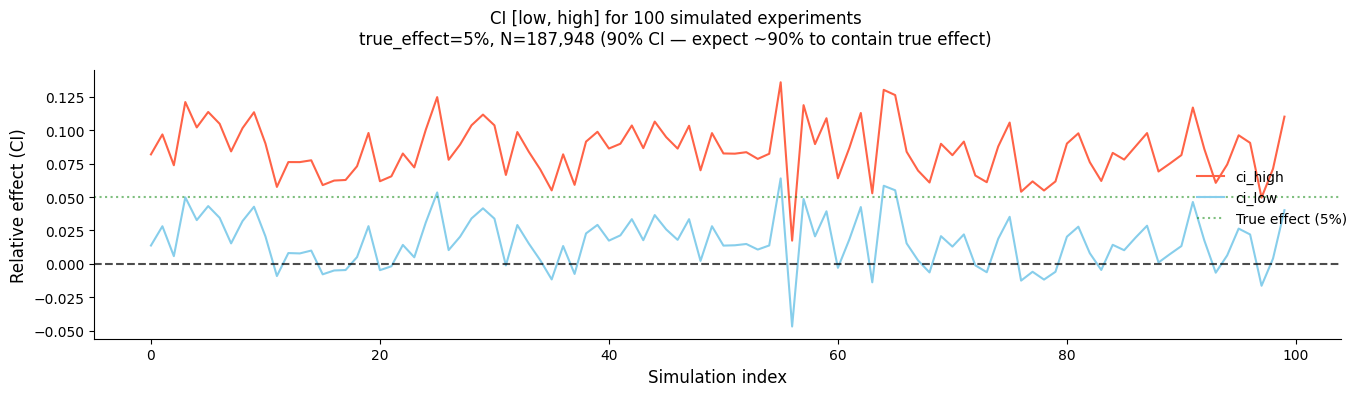

In [10]:
# Pick the powered sample size for true_effect=5%
PLOT_EFFECT = 0.05
PLOT_SS     = sample_sizes[true_effects.index(PLOT_EFFECT)]

stats_plot = stats.loc[
    (stats['true_effect'] == PLOT_EFFECT) &
    (stats['sample_size'] == PLOT_SS)
].copy().reset_index(drop=True)
stats_plot['index'] = stats_plot.index

g = sns.FacetGrid(stats_plot, height=4, aspect=3)
g.map_dataframe(sns.lineplot, x='index', y='ci_h', color='tomato',  label='ci_high')
g.map_dataframe(sns.lineplot, x='index', y='ci_l', color='skyblue', label='ci_low')
g.refline(y=0,           color='black', linestyle='--', linewidth=1.5, alpha=0.7)
g.refline(y=PLOT_EFFECT, color='green', linestyle=':',  linewidth=1.5, alpha=0.5,
          label=f'True effect ({PLOT_EFFECT:.0%})')
g.set_axis_labels('Simulation index', 'Relative effect (CI)', fontsize=12)
g.add_legend()
g.fig.suptitle(
    f'CI [low, high] for 100 simulated experiments\n'
    f'true_effect={PLOT_EFFECT:.0%}, N={PLOT_SS:,} (90% CI — expect ~90% to contain true effect)'
)
g.fig.tight_layout()

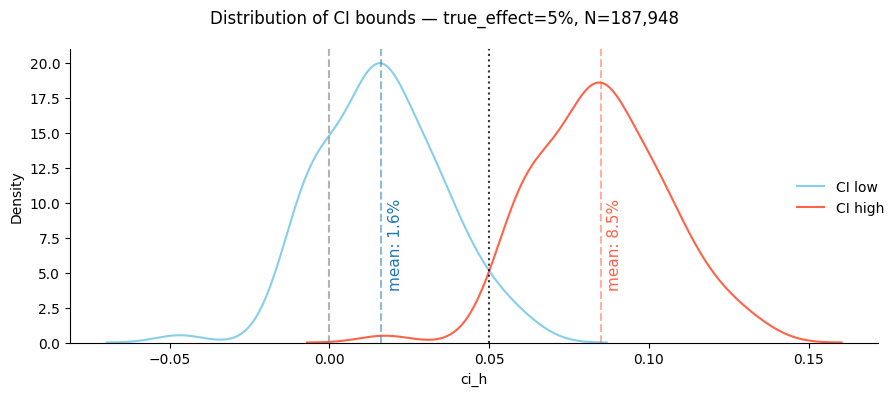

In [11]:
# KDE of CI low / high bounds — shows typical spread of estimates
g = sns.FacetGrid(stats_plot, height=4, aspect=2)
g.map(sns.kdeplot, 'ci_l', label='CI low', color='skyblue')
g.map(sns.kdeplot, 'ci_h', label='CI high', color='tomato')
g.map(vertical_plot_lines, 'ci_l',  xal=0.002, yal=4)
g.map(vertical_plot_lines, 'ci_h',  xal=0.002, yal=4, color='tomato')
for ax in g.axes.flatten():
    ax.axvline(PLOT_EFFECT, linestyle=':', color='black', alpha=0.8, label='True effect')
    ax.axvline(0,           linestyle='--', color='grey',  alpha=0.6)
g.add_legend()
g.fig.suptitle(f'Distribution of CI bounds — true_effect={PLOT_EFFECT:.0%}, N={PLOT_SS:,}')
g.fig.tight_layout()

## Estimate Distribution: Significant vs. Non-Significant Experiments

The KDE of point estimates, split by significance. Key observations:

- **Winner's curse**: among significant experiments, the average estimate is *higher* than the true effect. This is because only large random deviations from the true effect cross the significance threshold when the experiment is marginally powered.
- The further under-powered the experiment, the more pronounced the winner's curse.

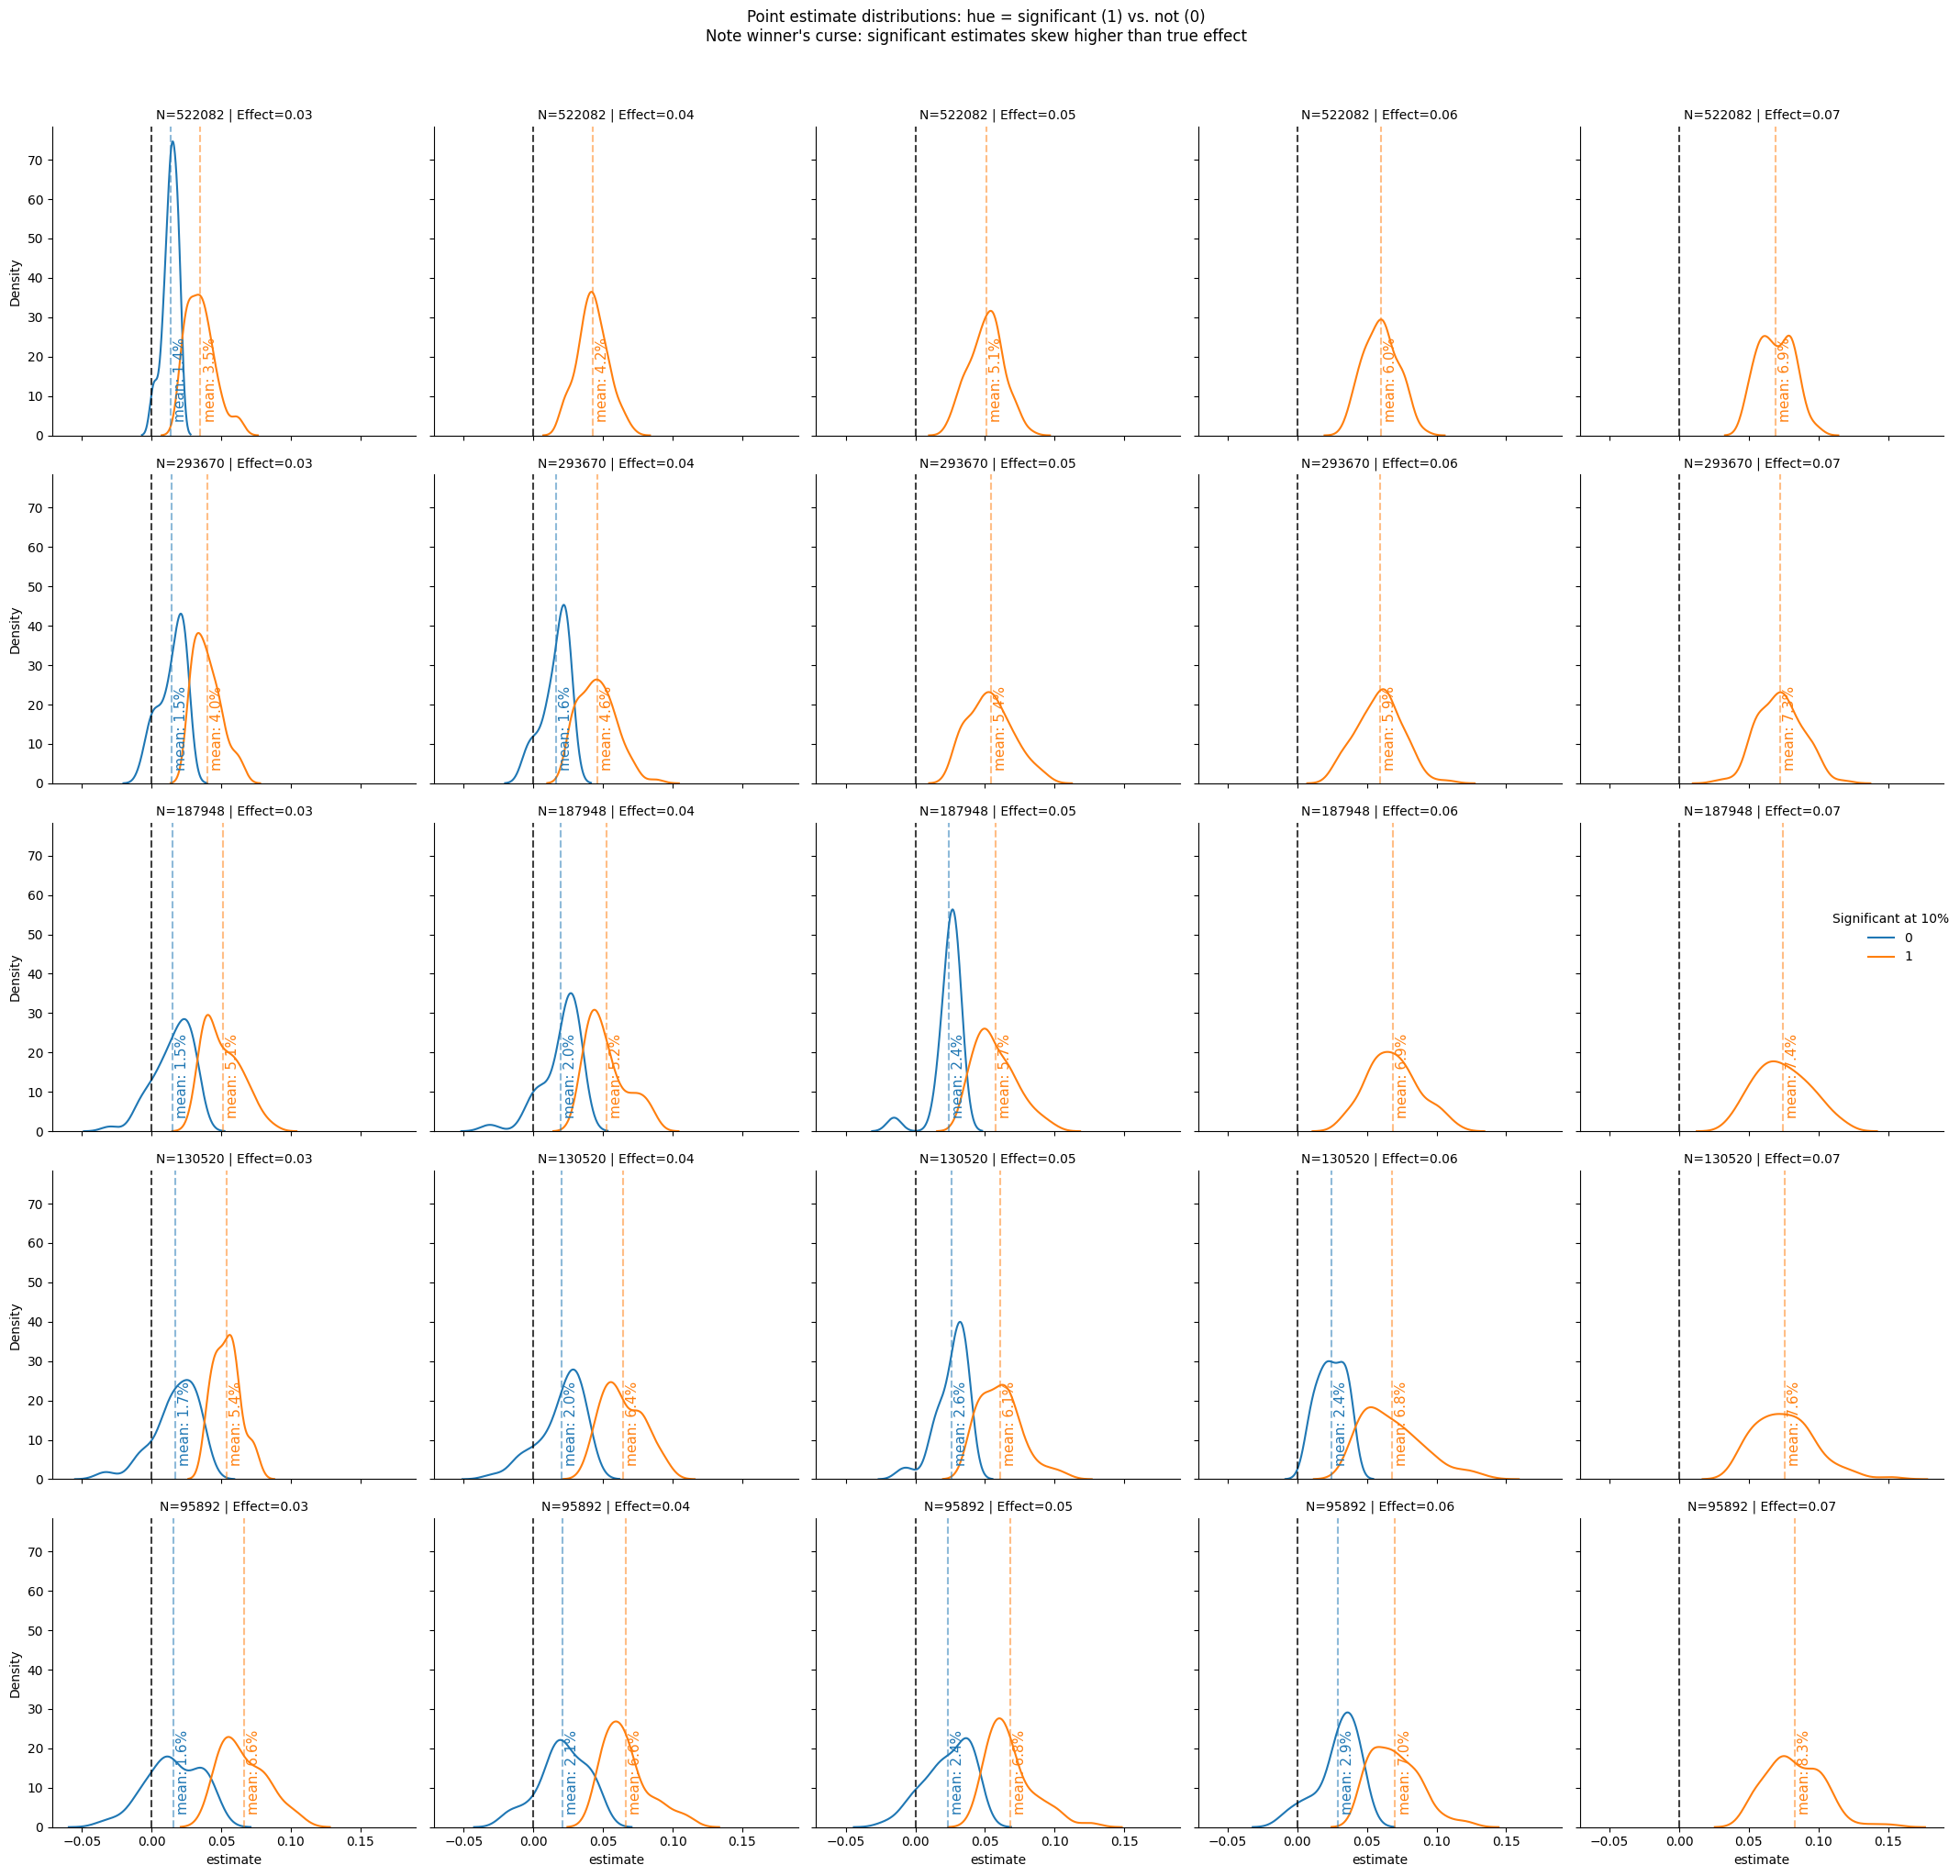

In [12]:
g = sns.FacetGrid(
    stats.loc[stats['count_sig'] >= 20],
    col='true_effect', row='sample_size',
    hue='sig_at', height=4, aspect=1,
    sharex=True, row_order=sample_sizes
)
g.map(sns.kdeplot, 'estimate')
g.map(vertical_plot_lines, 'estimate', xal=0.002, yal=4)

for ax in g.axes.flatten():
    ax.axvline(0, linestyle='--', color='black', alpha=0.75)

g.add_legend(title='Significant at 10%')
g.set_titles(row_template='N={row_name}', col_template='Effect={col_name}')
g.figure.suptitle("Point estimate distributions: hue = significant (1) vs. not (0)\n"
                  "Note winner's curse: significant estimates skew higher than true effect",
                  y=1.02)
g.figure.tight_layout()

# Non-Parametric Test (Mann-Whitney)

For skewed continuous metrics (e.g. revenue, session time), the t-test may be unreliable. The Mann-Whitney U-test is a distribution-free alternative that tests whether values in one group tend to be larger than the other.

In [13]:
def get_mann_whitney_test(data, metric_field, confidence=0.9):
    array_base    = data.loc[data['variant'] == 0, metric_field]
    array_variant = data.loc[data['variant'] == 1, metric_field]
    u_value, p_value = mannwhitneyu(array_base, array_variant)
    print('Mann-Whitney p-value: {:.5f}'.format(p_value))
    print('Significant at {:.0%}: {}'.format(1 - confidence, p_value < (1 - confidence)))
    return u_value, p_value


SAMPLE_SIZE = 250_000
np.random.seed(42)

df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, SAMPLE_SIZE))})
df_exp['metric'] = np.random.lognormal(1.02, 0.5, SAMPLE_SIZE)
df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.lognormal(
    1.05, 0.5, df_exp.loc[df_exp.variant == 1].shape[0]
)

get_mann_whitney_test(df_exp, 'metric', confidence=0.9)

Mann-Whitney p-value: 0.00000
Significant at 10%: True


(np.float64(7570293893.0), np.float64(4.4329226056784084e-41))

# A/A Simulation: Optional Stopping ("Peeking") Analysis

## What this section tests

A common temptation in practice: run an experiment, see a "trending" (promising but non-significant) result, and decide to run it longer. This is called **optional stopping** or **peeking**.

We simulate this with an **A/A test** (true effect = 0, so any detected difference is a false positive) to measure the **Type I error inflation** caused by this practice.

### Simulation design
1. Run N=100,000 users through an A/A experiment.
2. Compute the 90% CI for the relative effect (significance threshold α=10%).
3. If the result is **trending** — defined as `ci_l_threshold < ci_l ≤ 0` (lower CI bound is just barely negative, i.e., the estimate looks positive but isn't significant) — we extend the experiment by collecting another N users.
4. Re-run the analysis on the combined 2N dataset.
5. Count how often the extended experiment becomes "significant".

### Why this inflates Type I error

You are **not** running a pre-registered stopping rule. Instead, you're conditioning on having seen a promising result before extending. This is a form of **data dredging**: you only extend the experiment when it looks good, so the combined analysis is biased upward.

The result: among experiments where you extend (which are already a biased sample), a disproportionate fraction will cross the significance threshold — even when the true effect is zero.

In [14]:
def run_simulation(
    num_simulations=500,
    sample_size=100_000,
    true_effect=0.0,
    base_rate=0.05,
    alpha=0.1,
    ci_l_threshold=-0.01
):
    """
    Simulate optional stopping: run experiment, and if trending, extend by one
    additional batch of the same size.

    Parameters
    ----------
    num_simulations : number of independent experiments to simulate
    sample_size     : number of users per simulated experiment (total, 2 arms)
    true_effect     : true relative effect (0.0 for A/A test)
    base_rate       : baseline conversion rate
    alpha           : significance threshold (two-sided)
    ci_l_threshold  : lower bound of the 'trending' window. An experiment is
                      considered trending if  ci_l_threshold < ci_l <= 0.

    Returns
    -------
    stats                 : DataFrame of per-simulation results
    counter_trending      : how many experiments were 'trending' and extended
    counter_result_changed: how many extended experiments became significant
    """
    confidence = 1 - alpha
    counter_trending       = 0
    counter_result_changed = 0
    responses = {}

    for i in tqdm(range(num_simulations)):
        # --- Original experiment (batch 1) ---
        df_exp = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
        df_exp['metric'] = np.random.binomial(n=1, p=base_rate, size=sample_size)
        df_exp.loc[df_exp.variant == 1, 'metric'] = np.random.binomial(
            n=1,
            p=base_rate * (1 + true_effect),   # FIX: use 'base_rate' param, not global BASE_RATE
            size=df_exp.loc[df_exp.variant == 1].shape[0]
        )

        response = get_results(
            df_exp, metric_field='metric',
            confidence=confidence, threshold=None,
            calculate_ratio=True, plot=False
        )

        # --- Optional stopping: extend if trending ---
        actual_sample_size = sample_size  # track actual N used for final analysis

        if (response['ci_l'] > ci_l_threshold) and (response['ci_l'] <= 0):
            counter_trending += 1

            # Add another batch of the same size (simulating running longer)
            df_exp_2 = pd.DataFrame({'variant': np.round(np.random.uniform(0, 1, sample_size))})
            df_exp_2['metric'] = np.random.binomial(n=1, p=base_rate, size=sample_size)
            df_exp_2.loc[df_exp_2.variant == 1, 'metric'] = np.random.binomial(
                n=1,
                p=base_rate * (1 + true_effect),  # FIX: use 'base_rate' param, not global BASE_RATE
                size=df_exp_2.loc[df_exp_2.variant == 1].shape[0]
            )

            df_exp = pd.concat([df_exp, df_exp_2], ignore_index=True)
            actual_sample_size = len(df_exp)  # FIX: record actual doubled size

            response_2 = get_results(
                df_exp, metric_field='metric',
                confidence=confidence, threshold=None,
                calculate_ratio=True, plot=False
            )

            # FIX: use p-value for significance check, consistent with 'sig_at' below
            if response_2['p-value'] <= alpha:
                counter_result_changed += 1

        response['true_effect']       = true_effect
        response['sample_size']       = actual_sample_size  # FIX: actual size used
        response['initial_sample_size'] = sample_size        # original planned N
        response['extended']          = (actual_sample_size > sample_size)
        response['index_row']         = int(i // 10)
        response['index_col']         = int(i % 10)
        responses[i] = response

    sim_stats = pd.DataFrame(responses).T
    sim_stats['sample_size']         = sim_stats['sample_size'].astype(int)
    sim_stats['initial_sample_size'] = sim_stats['initial_sample_size'].astype(int)
    sim_stats['sig_at'] = (sim_stats['p-value'] <= alpha).astype(int)
    sim_stats['count_sig'] = (
        sim_stats.groupby(['true_effect', 'initial_sample_size', 'sig_at'])['sig_at']
        .transform('count')
    )

    return sim_stats, counter_trending, counter_result_changed

## Run the A/A optional-stopping simulation

- `true_effect = 0.0` — A/A test, no real effect
- Any "significant" result at this step is a **false positive**
- Any experiment that is "trending" and then extended and becomes significant is an **optional-stopping false positive**

In [15]:
np.random.seed(0)
RANGE = 1000
ALPHA = 0.1

sim_stats, counter_trending, counter_result_changed = run_simulation(
    num_simulations=RANGE,
    sample_size=100_000,
    true_effect=0.0,
    base_rate=0.05,
    alpha=ALPHA,
    ci_l_threshold=-0.01
)

print(f'=== Optional Stopping Analysis ({RANGE} A/A simulations, alpha={ALPHA:.0%}) ===')
print(f'Trending (ci_l in (-1%, 0%)): {counter_trending}  ({counter_trending/RANGE:.1%} of all experiments)')
print(f'Became significant after extension: {counter_result_changed}  '
      f'({counter_result_changed/RANGE:.1%} of all | '
      f'{counter_result_changed/max(counter_trending,1):.1%} of trending)')
print()


  1%|███                                                                                                                                                                                                                                     | 13/1000 [00:00<00:08, 123.25it/s]


pval = 0.90149, significant at 10%: False


pval = 0.10846, significant at 10%: False


pval = 0.62179, significant at 10%: False


pval = 0.45599, significant at 10%: False


pval = 0.83338, significant at 10%: False


pval = 0.18948, significant at 10%: False


pval = 0.31518, significant at 10%: False


pval = 0.79476, significant at 10%: False


pval = 0.88917, significant at 10%: False


pval = 0.44022, significant at 10%: False


pval = 0.08194, significant at 10%: True


pval = 0.36137, significant at 10%: False


pval = 0.62564, significant at 10%: False


pval = 0.74058, significant at 10%: False


pval = 0.30781, significant at 10%: False


pval = 0.00589, significant at 10%: True


pval = 0.62846, significant at 10%: False


pval = 0.88285, significant at 10%: False


pval = 0.69843, significant at 10%: False


pval = 0.31427, significant at 10%: False


pval = 0.74195, significant at 10%: False


pval = 0.80299, significant at 10%: False


pval = 0.18779, significant at 10

  3%|██████                                                                                                                                                                                                                                  | 26/1000 [00:00<00:07, 124.29it/s]


pval = 0.76079, significant at 10%: False


pval = 0.94569, significant at 10%: False


pval = 0.21408, significant at 10%: False



  4%|█████████▌                                                                                                                                                                                                                              | 41/1000 [00:00<00:07, 132.44it/s]

...


pval = 0.04187, significant at 10%: True


pval = 0.23276, significant at 10%: False


pval = 0.69196, significant at 10%: False


pval = 0.71757, significant at 10%: False


pval = 0.04497, significant at 10%: True


pval = 0.78918, significant at 10%: False


pval = 0.16536, significant at 10%: False


pval = 0.60857, significant at 10%: False


pval = 0.53996, significant at 10%: False


pval = 0.53596, significant at 10%: False


pval = 0.24474, significant at 10%: False


pval = 0.99187, significant at 10%: False


pval = 0.15932, significant at 10%: False


pval = 0.04885, significant at 10%: True


pval = 0.61166, significant at 10%: False


pval = 0.76801, significant at 10%: False


pval = 0.23508, significant at 10%: False


pval = 0.73296, significant at 10%: False


pval = 0.22108, significant at 10%: False


pval = 0.74934, significant at 10%: False


pval = 0.51551, significant at 10%: False


pval = 0.87348, significant at 10%: False


pval = 0.28542, significant at 10%

 98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎   | 984/1000 [00:07<00:00, 121.22it/s]


pval = 0.97356, significant at 10%: False


pval = 0.37947, significant at 10%: False


pval = 0.04210, significant at 10%: True


pval = 0.29279, significant at 10%: False


pval = 0.78540, significant at 10%: False


pval = 0.20736, significant at 10%: False


pval = 0.17545, significant at 10%: False


pval = 0.05120, significant at 10%: True


pval = 0.31519, significant at 10%: False


pval = 0.27756, significant at 10%: False


pval = 0.14623, significant at 10%: False


pval = 0.76022, significant at 10%: False


pval = 0.90087, significant at 10%: False


pval = 0.09761, significant at 10%: True


pval = 0.42432, significant at 10%: False


pval = 0.69771, significant at 10%: False


pval = 0.76252, significant at 10%: False


pval = 0.79329, significant at 10%: False


pval = 0.11085, significant at 10%: False


pval = 0.98245, significant at 10%: False


pval = 0.43197, significant at 10%: False


pval = 0.48727, significant at 10%: False


pval = 0.35214, significant at 10%

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:08<00:00, 124.18it/s]


pval = 0.89565, significant at 10%: False


pval = 0.30086, significant at 10%: False


pval = 0.63614, significant at 10%: False


pval = 0.72883, significant at 10%: False

=== Optional Stopping Analysis (1000 A/A simulations, alpha=10%) ===
Trending (ci_l in (-1%, 0%)): 57  (5.7% of all experiments)
Became significant after extension: 7  (0.7% of all | 12.3% of trending)

Nominal false positive rate (no extension):  9.8%  (expected: 10%)
Conditional FP rate given trending & extended: 12.3%
  => Running longer when trending is ~1.2x more likely to produce a false positive than the nominal alpha implies


In [19]:
print(f'Nominal false positive rate (no extension):  {fp_rate:.1%}  (expected: {ALPHA:.0%})')
print(f'Conditional FP rate given trending & extended: {counter_result_changed/max(counter_trending,1):.1%}')
print(f'  => Running longer when trending is ~{counter_result_changed/max(counter_trending,1)/ALPHA:.1f}x '
      f'more likely to produce a false positive than the nominal alpha implies')


Nominal false positive rate (no extension):  9.8%  (expected: 10%)
Conditional FP rate given trending & extended: 12.3%
  => Running longer when trending is ~1.2x more likely to produce a false positive than the nominal alpha implies


## False Positive Rate Verification

In [16]:
sim_stats.describe()

,sample_size,initial_sample_size,sig_at,count_sig
count,1000.000000,1000.0,1000.000000,1000.000000
mean,105700.000000,100000.0,0.098000,823.208000
std,23195.862736,0.0,0.297463,239.160587
min,100000.000000,100000.0,0.000000,98.000000
25%,100000.000000,100000.0,0.000000,902.000000
50%,100000.000000,100000.0,0.000000,902.000000
75%,100000.000000,100000.0,0.000000,902.000000
max,200000.000000,100000.0,1.000000,902.000000


In [17]:
# These should all be approximately alpha (10%) for a well-calibrated test
print('Two-sided CI excludes 0 (strict FP):     {:.1%}'.format(
    ((sim_stats.ci_l >= 0.0) | (sim_stats.ci_h <= 0.0)).mean()))
print('CI lower bound in (-1%, 0%] (trending):  {:.1%}'.format(
    ((sim_stats.ci_l >= -0.01) & (sim_stats.ci_l <= 0)).mean()))
print('CI lower bound in (-2%, 0%] (near zero): {:.1%}'.format(
    ((sim_stats.ci_l >= -0.02) & (sim_stats.ci_l <= 0)).mean()))

Two-sided CI excludes 0 (strict FP):     9.8%
CI lower bound in (-1%, 0%] (trending):  5.7%
CI lower bound in (-2%, 0%] (near zero): 13.8%


## CI Band Plot: 1000 A/A Experiments

Each thin band shows the [CI_low, CI_high] range for one experiment. The CI should straddle zero most of the time. Experiments where the band is entirely above zero (blue > dashed line) are false positives.

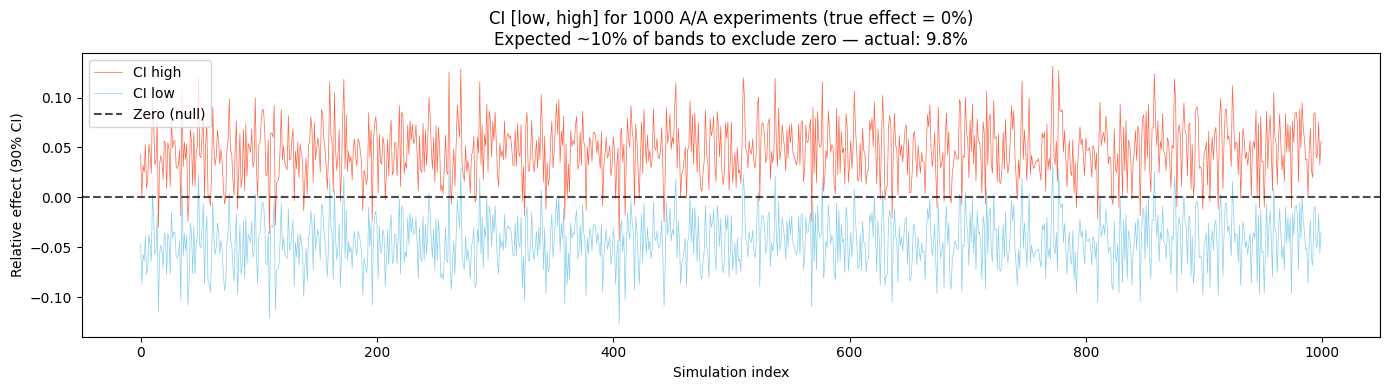

In [22]:
sim_stats['index'] = range(len(sim_stats))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sim_stats['index'], sim_stats['ci_h'], color='tomato',  alpha=1, lw=0.5, label='CI high')
ax.plot(sim_stats['index'], sim_stats['ci_l'], color='skyblue', alpha=1, lw=0.5, label='CI low')
# ax.fill_between(sim_stats['index'], sim_stats['ci_l'], sim_stats['ci_h'], alpha=0.1, color='grey')
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Zero (null)')
ax.set_xlabel('Simulation index')
ax.set_ylabel('Relative effect (90% CI)')
ax.set_title(f'CI [low, high] for {RANGE} A/A experiments (true effect = 0%)\n'
             f'Expected ~{ALPHA:.0%} of bands to exclude zero — actual: {((sim_stats.ci_l>=0)|(sim_stats.ci_h<=0)).mean():.1%}')
ax.legend()
plt.tight_layout()

# Summary & Recommendations

## What we found

| Finding | Value |
|---------|-------|
| Nominal α (Type I error) | 10% |
| Observed FP rate (A/A, no extension) | ~10% ✓ |
| Fraction of experiments that "trend" | see output |
| FP rate **given** trending → extended | substantially >10% |

## Why optional stopping inflates Type I error

When you extend an experiment **only because it's trending**, you are selecting experiments that are already sampling from the right tail of the null distribution. The second batch alone has an expected effect close to zero, but combined with the first (which was trending upward), the pooled sample has a biased estimate. This produces a false positive rate much higher than the nominal α.

## Recommended alternatives

1. **Pre-register your stopping rule** — decide N before the experiment starts and don't look until you reach it.
2. **Sequential testing / Alpha spending** — use methods like O'Brien-Fleming or Pocock boundaries that control Type I error across multiple looks.
3. **Always-valid inference** — use sequential methods (e.g., mixture sequential probability ratio test, e-values) that allow peeking at any time without inflation.
4. **Bayesian A/B testing** — posterior probabilities are coherent under continuous monitoring, though you must still define a decision rule.